# Classificação de gestos faciais com SVM

Este notebook constrói um fluxo completo de classificação para o arquivo `TreatedData.csv`. As etapas são: leitura e entendimento dos dados, verificação de qualidade, análise das classes, separação em treino/validação/teste, padronização, escolha do hiperparâmetro `C` com a validação e avaliação final no teste.

Bibliotecas principais: **pandas** para manipulação dos dados, **matplotlib** para os gráficos e **scikit-learn** para divisão, pré-processamento, treinamento e métricas.

## 1. Configuração

O CSV possui 1.404 atributos (as coordenadas `x`, `y` e `z` de 468 landmarks faciais). Neste experimento será usada a classe `SVC` com kernel RBF, capaz de criar fronteiras não lineares. Como o RBF é mais custoso que uma SVM linear, o cache do kernel é ampliado e uma grade compacta de `C` e `gamma` é comparada na validação temporal.

A semente aleatória torna a divisão reproduzível. O caminho do CSV é procurado tanto a partir da pasta `notebooks` quanto da raiz do projeto.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
TARGET_COLUMN = "0"
CLASS_NAMES = {3: "Sobrancelhas levantadas", 4: "Boca aberta"}

candidate_paths = [Path("../data/TreatedData.csv"), Path("data/TreatedData.csv")]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("TreatedData.csv não foi encontrado na pasta data.")

print(f"Arquivo utilizado: {DATA_PATH.resolve()}")

Arquivo utilizado: C:\Users\tamj4\Desktop\Projeto_lúcidio\DinoGesture\data\TreatedData.csv


## 2. Leitura e organização do dataset

As coordenadas são mantidas em `float64`, o tipo numérico inferido por padrão pelo `pandas`, sem conversão para `float32`. A coluna `Unnamed: 0` é apenas um índice que foi salvo no CSV e não descreve o rosto; por isso, ela é removida para impedir que o modelo aprenda a ordem das linhas. A coluna `0` é o rótulo que queremos prever.

In [2]:
dataset = pd.read_csv(DATA_PATH, memory_map=True)

index_columns = [column for column in dataset.columns if column.startswith("Unnamed:")]
if TARGET_COLUMN not in dataset.columns:
    raise KeyError(f"A coluna alvo {TARGET_COLUMN!r} não existe no CSV.")

original_index = dataset[index_columns[0]].copy() if index_columns else pd.Series(dataset.index)
dataset = dataset.drop(columns=index_columns)
dataset[TARGET_COLUMN] = dataset[TARGET_COLUMN].astype("int16")

X = dataset.drop(columns=TARGET_COLUMN)
y = dataset[TARGET_COLUMN]



In [3]:
display(dataset.iloc[:5, :10])
print("Primeiras 10 colunas:", dataset.columns[:10].tolist())
print("Tipo dos atributos:", X.dtypes.iloc[0])

,0,X_0,Y_0,Z_0,X_1,Y_1,Z_1,X_2,Y_2,Z_2
0,3,0.480316,0.522955,-0.038981,0.483750,0.496124,-0.083564,0.483050,0.503859,-0.042683
1,3,0.481082,0.523268,-0.039329,0.484299,0.496527,-0.083353,0.483830,0.504162,-0.042776
2,3,0.481146,0.523485,-0.038708,0.484601,0.496378,-0.083276,0.484121,0.504084,-0.042318
3,3,0.481022,0.522546,-0.038745,0.484630,0.496284,-0.083493,0.484004,0.503810,-0.042262
4,3,0.481739,0.523413,-0.039082,0.485431,0.496454,-0.084576,0.484669,0.504108,-0.043229


Primeiras 10 colunas: ['0', 'X_0', 'Y_0', 'Z_0', 'X_1', 'Y_1', 'Z_1', 'X_2', 'Y_2', 'Z_2']
Tipo dos atributos: float64


## 3. Pequena análise inicial

Antes do treinamento, verificamos valores ausentes, valores infinitos e atributos constantes. Valores ausentes ou infinitos impedem o treinamento de uma SVM; atributos constantes não ajudam a separar as classes. Também resumimos as escalas das coordenadas para entender a faixa numérica das entradas.

In [4]:
X_array = X.to_numpy(copy=False)
missing_values = int(X.isna().sum().sum())
infinite_values = int(np.isinf(X_array).sum())
constant_features = int(X.std(axis=0).eq(0).sum())

quality_summary = pd.DataFrame({
    "verificação": ["Valores ausentes", "Valores infinitos", "Atributos constantes"],
    "quantidade": [missing_values, infinite_values, constant_features],
})
quality_summary

,verificação,quantidade
0,Valores ausentes,0
1,Valores infinitos,0
2,Atributos constantes,0


In [5]:
axis_summaries = []
for axis in ["X", "Y", "Z"]:
    values = X.filter(regex=rf"^{axis}_").to_numpy(copy=False)
    axis_summaries.append({
        "eixo": axis.lower(),
        "mínimo": float(values.min()),
        "média": float(values.mean()),
        "desvio-padrão": float(values.std()),
        "máximo": float(values.max()),
    })

pd.DataFrame(axis_summaries).set_index("eixo").round(4)

,mínimo,média,desvio-padrão,máximo
eixo,,,,
x,0.0546,0.5015,0.0692,0.8232
y,0.1560,0.4253,0.0810,0.7379
z,-0.1397,-0.0000,0.0337,0.2771


### 3.1 Distribuição das classes

A contagem por classe mostra quantos exemplos existem de cada gesto. Uma diferença grande exigiria atenção especial; neste fluxo, `class_weight='balanced'` também ajusta automaticamente a importância de cada classe durante o treinamento.

,classe,amostras,gesto,percentual
0,3,15440,Sobrancelhas levantadas,47.557445
1,4,17026,Boca aberta,52.442555


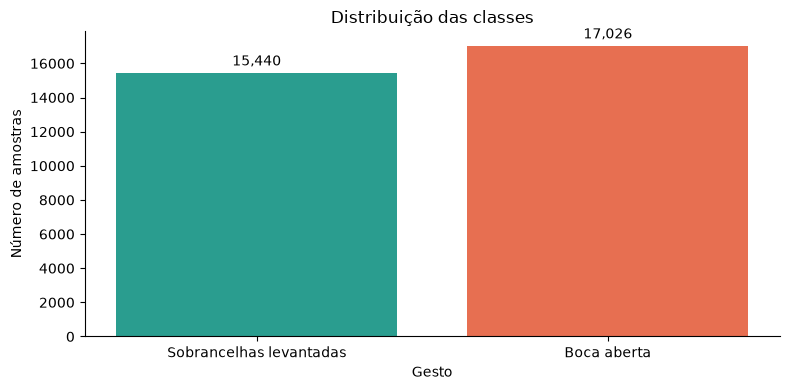

In [6]:
class_distribution = (
    y.value_counts()
    .sort_index()
    .rename_axis("classe")
    .reset_index(name="amostras")
)
class_distribution["gesto"] = class_distribution["classe"].map(CLASS_NAMES)
class_distribution["percentual"] = 100 * class_distribution["amostras"] / len(y)
display(class_distribution)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    class_distribution["gesto"],
    class_distribution["amostras"],
    color=["#2a9d8f", "#e76f51"],
)
ax.bar_label(bars, fmt="{:,.0f}", padding=3)
ax.set(title="Distribuição das classes", xlabel="Gesto", ylabel="Número de amostras")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 3.2 Ordem dos registros e risco de vazamento

Os rótulos aparecem em grandes blocos consecutivos e linhas vizinhas são frames muito semelhantes. Por isso, uma divisão aleatória colocaria quase o mesmo frame em treino e teste. Como não existem identificadores de pessoa ou sessão, adotaremos a alternativa mais conservadora possível com os dados disponíveis: divisão cronológica dentro de cada classe, sem embaralhamento, com uma faixa de 4.000 frames descartados entre os subconjuntos.

Blocos consecutivos de classe: 2


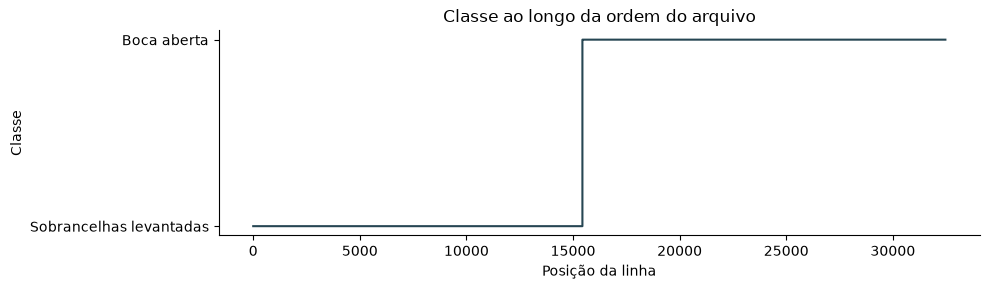

In [7]:
label_changes = int(y.ne(y.shift()).sum())
print(f"Blocos consecutivos de classe: {label_changes}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.step(np.arange(len(y)), y, where="post", color="#264653")
ax.set(
    title="Classe ao longo da ordem do arquivo",
    xlabel="Posição da linha",
    ylabel="Classe",
)
ax.set_yticks(sorted(y.unique()), [CLASS_NAMES.get(label, str(label)) for label in sorted(y.unique())])
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Limpeza preventiva

Se houver algum valor infinito, ele é convertido em ausente. As linhas exatamente duplicadas são removidas antes da divisão, impedindo que uma cópia idêntica apareça em outro subconjunto. Quando necessário, cada valor ausente é preenchido pela mediana calculada **somente no conjunto de treino** através do pipeline. Os atributos constantes também são removidos dentro do pipeline com `VarianceThreshold`.

In [8]:
if infinite_values:
    dataset = dataset.replace([np.inf, -np.inf], np.nan)

rows_before_deduplication = len(dataset)
dataset = dataset.drop_duplicates(keep="first").reset_index(drop=True)
duplicates_removed = rows_before_deduplication - len(dataset)

X = dataset.drop(columns=TARGET_COLUMN)
y = dataset[TARGET_COLUMN]

print(f"Duplicatas exatas removidas: {duplicates_removed:,}")
print(f"Formato usado na modelagem: {X.shape}")

Duplicatas exatas removidas: 122
Formato usado na modelagem: (32344, 1404)


## 5. Divisão em treino, validação e teste

A divisão é feita separadamente dentro de cada classe, preservando a ordem original dos frames. Depois de reservar duas faixas de segurança, os registros utilizáveis de cada classe são distribuídos em aproximadamente **70% treino, 15% validação e 15% teste**.

Entre treino e validação, e novamente entre validação e teste, são descartados **4.000 frames por classe**. Esse valor foi escolhido porque, neste arquivo, a diferença entre frames separados por 4.000 posições já alcança a variação observada entre pares aleatórios da mesma classe. O custo é usar menos dados, mas a estimativa se torna muito mais honesta.

- **Treino:** ajusta os parâmetros do modelo.
- **Validação:** escolhe o melhor valor de `C`.
- **Teste:** fica intocado até a avaliação final.

In [9]:
PURGE_SIZE = 4_000


def purged_temporal_split(target, purge_size=PURGE_SIZE):
    train_indices = []
    valid_indices = []
    test_indices = []
    discarded_indices = []
    range_rows = []
    target_array = target.to_numpy()

    for label in sorted(target.unique()):
        class_indices = np.flatnonzero(target_array == label)
        usable_samples = len(class_indices) - 2 * purge_size
        if usable_samples <= 0:
            raise ValueError(
                f"A classe {label} não possui registros suficientes para "
                f"duas faixas de {purge_size} frames."
            )

        train_size = int(usable_samples * 0.70)
        valid_size = int(usable_samples * 0.15)
        train_end = train_size
        valid_start = train_end + purge_size
        valid_end = valid_start + valid_size
        test_start = valid_end + purge_size

        class_train = class_indices[:train_end]
        first_purge = class_indices[train_end:valid_start]
        class_valid = class_indices[valid_start:valid_end]
        second_purge = class_indices[valid_end:test_start]
        class_test = class_indices[test_start:]

        train_indices.extend(class_train)
        valid_indices.extend(class_valid)
        test_indices.extend(class_test)
        discarded_indices.extend(first_purge)
        discarded_indices.extend(second_purge)
        range_rows.append({
            "classe": label,
            "treino": len(class_train),
            "gap 1": len(first_purge),
            "validação": len(class_valid),
            "gap 2": len(second_purge),
            "teste": len(class_test),
        })

    return tuple(map(np.asarray, (
        train_indices, valid_indices, test_indices, discarded_indices
    ))), pd.DataFrame(range_rows)


(train_idx, valid_idx, test_idx, discarded_idx), temporal_ranges = purged_temporal_split(y)

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

# Auditoria 1: nenhum índice pode aparecer em mais de um conjunto.
split_sets = [set(train_idx), set(valid_idx), set(test_idx), set(discarded_idx)]
assert sum(len(indices) for indices in split_sets) == len(set().union(*split_sets))
assert sum(len(indices) for indices in split_sets) == len(X)

# Auditoria 2: confirma os gaps reais entre os intervalos de cada classe.
gap_audit_rows = []
for label in sorted(y.unique()):
    class_train = train_idx[y.iloc[train_idx].to_numpy() == label]
    class_valid = valid_idx[y.iloc[valid_idx].to_numpy() == label]
    class_test = test_idx[y.iloc[test_idx].to_numpy() == label]
    gap_audit_rows.append({
        "classe": label,
        "frames entre treino e validação": int(class_valid.min() - class_train.max() - 1),
        "frames entre validação e teste": int(class_test.min() - class_valid.max() - 1),
    })
gap_audit = pd.DataFrame(gap_audit_rows)
assert gap_audit.iloc[:, 1:].ge(PURGE_SIZE).all().all()

# Auditoria 3: nenhuma linha de features idêntica cruza os subconjuntos.
feature_hashes = pd.util.hash_pandas_object(X, index=False).to_numpy()
train_hashes = set(feature_hashes[train_idx])
valid_hashes = set(feature_hashes[valid_idx])
test_hashes = set(feature_hashes[test_idx])
duplicate_overlap = (
    len(train_hashes & valid_hashes)
    + len(train_hashes & test_hashes)
    + len(valid_hashes & test_hashes)
)
assert duplicate_overlap == 0

display(temporal_ranges)
display(gap_audit)
print(f"Duplicatas de features entre subconjuntos: {duplicate_overlap}")
split_summary = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste", "gaps descartados"],
    "amostras": [len(y_train), len(y_valid), len(y_test), len(discarded_idx)],
})
split_summary["percentual do dataset limpo"] = 100 * split_summary["amostras"] / len(X)
display(split_summary)

# Libera apenas as referências grandes que não serão mais usadas.
del X, y, dataset, X_array

,classe,treino,gap 1,validação,gap 2,teste
0,3,5161,4000,1106,4000,1107
1,4,6279,4000,1345,4000,1346


,classe,frames entre treino e validação,frames entre validação e teste
0,3,4000,4000
1,4,4000,4000


Duplicatas de features entre subconjuntos: 0


,conjunto,amostras,percentual do dataset limpo
0,treino,11440,35.369775
1,validação,2451,7.577912
2,teste,2453,7.584096
3,gaps descartados,16000,49.468217


,Sobrancelhas levantadas,Boca aberta
Treino,45.11,54.89
Validação,45.12,54.88
Teste,45.13,54.87


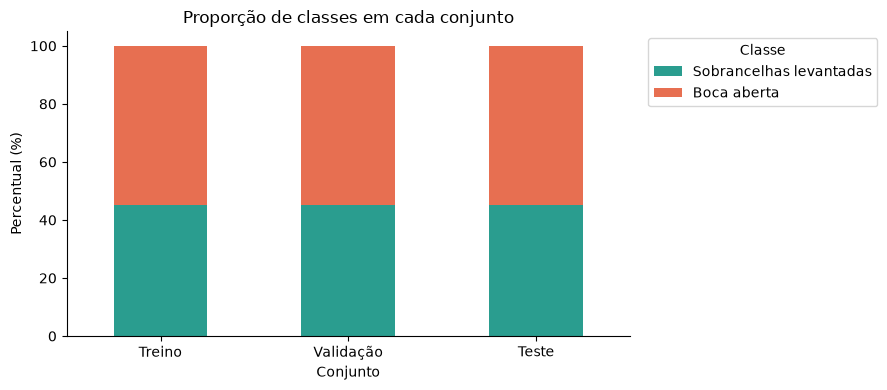

In [10]:
split_targets = {"Treino": y_train, "Validação": y_valid, "Teste": y_test}
split_proportions = pd.DataFrame({
    name: target.value_counts(normalize=True).sort_index() * 100
    for name, target in split_targets.items()
}).T
split_proportions.columns = [CLASS_NAMES.get(label, str(label)) for label in split_proportions.columns]
display(split_proportions.round(2))

ax = split_proportions.plot(
    kind="bar", stacked=True, figsize=(9, 4), color=["#2a9d8f", "#e76f51"]
)
ax.set(title="Proporção de classes em cada conjunto", xlabel="Conjunto", ylabel="Percentual (%)")
ax.legend(title="Classe", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Pipeline de pré-processamento e SVM

SVMs são sensíveis à escala. O `StandardScaler` transforma cada atributo usando a média e o desvio-padrão observados no treino. Ele fica dentro de um `Pipeline`, garantindo que validação e teste sejam apenas transformados com estatísticas aprendidas no treino e evitando vazamento de informação.

O kernel RBF mede similaridades e permite uma fronteira curva. O hiperparâmetro `C` controla a penalização por erros: valores menores regularizam mais; valores maiores tentam ajustar mais estritamente os dados de treino. O `gamma` controla o alcance do kernel: valores altos criam regiões locais e complexas, enquanto valores baixos geram uma fronteira mais suave. A combinação será escolhida exclusivamente pelo F1 macro da validação temporal.

In [11]:
def build_svm(c_value, gamma_value):
    steps = []
    if missing_values or infinite_values:
        steps.append(("imputer", SimpleImputer(strategy="median")))
    steps.extend([
        ("variance_filter", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("svm", SVC(
            C=c_value,
            kernel="rbf",
            gamma=gamma_value,
            class_weight="balanced",
            cache_size=1024,
        )),
    ])
    return Pipeline(steps)


C_VALUES = [0.1, 1.0, 10.0]
GAMMA_VALUES = [1e-5, 1e-4, 3e-4, "scale"]
validation_results = []

for gamma_value in GAMMA_VALUES:
    for c_value in C_VALUES:
        model = build_svm(c_value, gamma_value)

        start = time.perf_counter()
        model.fit(X_train, y_train)
        elapsed = time.perf_counter() - start
        train_prediction = model.predict(X_train)
        valid_prediction = model.predict(X_valid)
        train_f1 = f1_score(y_train, train_prediction, average="macro")
        valid_f1 = f1_score(y_valid, valid_prediction, average="macro")

        validation_results.append({
            "C": c_value,
            "gamma": gamma_value,
            "acurácia": accuracy_score(y_valid, valid_prediction),
            "acurácia balanceada": balanced_accuracy_score(y_valid, valid_prediction),
            "F1 macro treino": train_f1,
            "F1 macro validação": valid_f1,
            "gap F1 (p.p.)": 100 * (train_f1 - valid_f1),
            "tempo (s)": elapsed,
        })

validation_results = pd.DataFrame(validation_results).sort_values("F1 macro validação", ascending=False)
best_c = float(validation_results.iloc[0]["C"])
best_gamma = validation_results.iloc[0]["gamma"]
display(validation_results.style.format({
    "acurácia": "{:.4f}",
    "acurácia balanceada": "{:.4f}",
    "F1 macro treino": "{:.4f}",
    "F1 macro validação": "{:.4f}",
    "gap F1 (p.p.)": "{:.2f}",
    "tempo (s)": "{:.2f}",
}))
print(f"Melhor combinação na validação: C={best_c:g}, gamma={best_gamma}")

AttributeError: The '.style' accessor requires jinja2

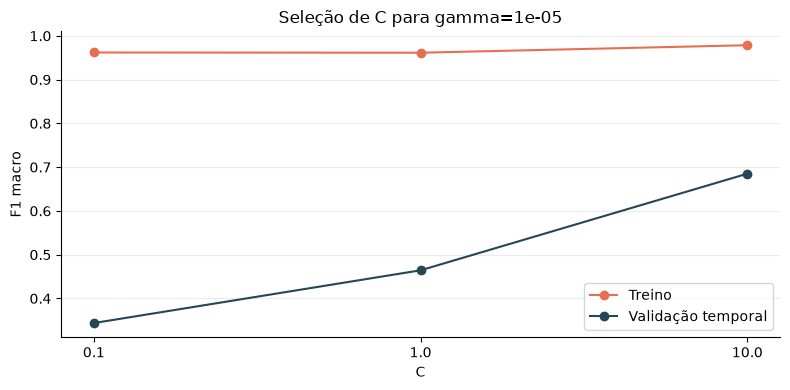

In [ ]:
ordered_results = validation_results[
    validation_results["gamma"].astype(str) == str(best_gamma)
].sort_values("C")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ordered_results["C"].astype(str), ordered_results["F1 macro treino"], marker="o", label="Treino", color="#e76f51")
ax.plot(ordered_results["C"].astype(str), ordered_results["F1 macro validação"], marker="o", label="Validação temporal", color="#264653")
ax.set(title=f"Seleção de C para gamma={best_gamma}", xlabel="C", ylabel="F1 macro")
ax.grid(axis="y", alpha=0.25)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Treinamento final e avaliação no teste

Depois de escolher `C`, o modelo final é reajustado com a união de treino e validação. Assim, ele aproveita 85% dos dados. Somente então o conjunto de teste é usado uma única vez para estimar o desempenho final.

In [ ]:
X_train_final = pd.concat([X_train, X_valid], axis=0)
y_train_final = pd.concat([y_train, y_valid], axis=0)

final_model = build_svm(best_c, best_gamma)

start = time.perf_counter()
final_model.fit(X_train_final, y_train_final)
final_train_seconds = time.perf_counter() - start
test_prediction = final_model.predict(X_test)

test_metrics = pd.Series({
    "Acurácia": accuracy_score(y_test, test_prediction),
    "Acurácia balanceada": balanced_accuracy_score(y_test, test_prediction),
    "F1 macro": f1_score(y_test, test_prediction, average="macro"),
    "Tempo de treino final (s)": final_train_seconds,
})
test_metrics.to_frame("resultado").style.format("{:.4f}")

,resultado
Acurácia,1.0000
Acurácia balanceada,1.0000
F1 macro,1.0000
Tempo de treino final (s),44.0784


In [ ]:
labels = sorted(y_test.unique())
report = classification_report(
    y_test,
    test_prediction,
    labels=labels,
    target_names=[CLASS_NAMES.get(label, str(label)) for label in labels],
    output_dict=True,
    zero_division=0,
)
pd.DataFrame(report).T.round(4)

,precision,recall,f1-score,support
Sobrancelhas levantadas,1.0,1.0,1.0,1107.0
Boca aberta,1.0,1.0,1.0,1346.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,2453.0
weighted avg,1.0,1.0,1.0,2453.0


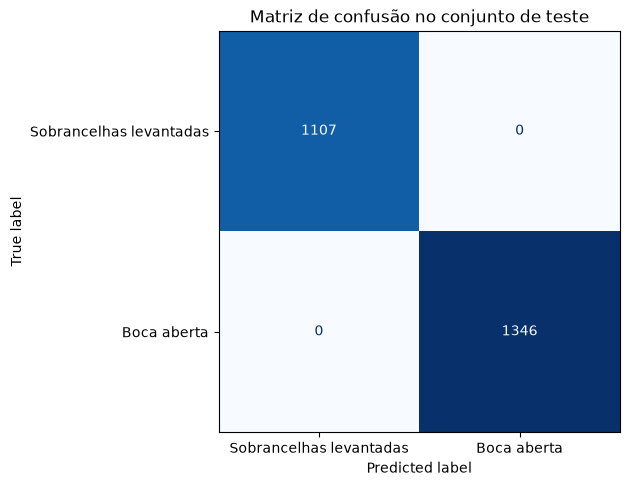

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    labels=labels,
    display_labels=[CLASS_NAMES.get(label, str(label)) for label in labels],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Matriz de confusão no conjunto de teste")
plt.tight_layout()
plt.show()

## 8. Demonstração visual da separação não linear

O modelo principal separa as classes em um espaço de até 1.404 dimensões, que não pode ser desenhado diretamente em uma tela 2D. Para criar uma demonstração compreensível, aplicamos **PCA** aos atributos já pré-processados e projetamos os exemplos nos dois componentes principais.

Em seguida, treinamos um **SVC com kernel RBF auxiliar somente nessas duas dimensões** e desenhamos sua fronteira curva. O gráfico ilustra o comportamento não linear do kernel, mas não representa perfeitamente a fronteira do modelo completo, pois parte da informação fica nos demais componentes. O PCA é ajustado apenas em treino + validação, e o teste é somente projetado.

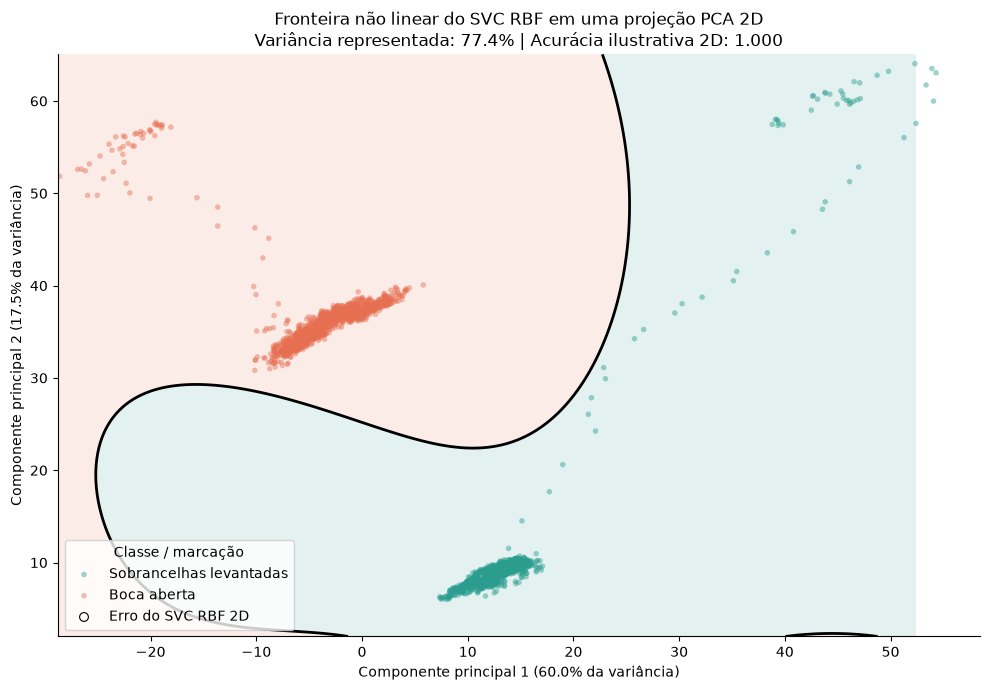

In [ ]:
# Reutiliza exatamente o pré-processamento aprendido pelo modelo final.
X_train_processed = final_model[:-1].transform(X_train_final)
X_test_processed = final_model[:-1].transform(X_test)

pca = PCA(n_components=2, svd_solver="randomized", random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_processed)
X_test_2d = pca.transform(X_test_processed)

visual_svm = SVC(
    C=best_c,
    kernel="rbf",
    gamma="scale",
    class_weight="balanced",
    cache_size=512,
)
visual_svm.fit(X_train_2d, y_train_final)
visual_prediction = visual_svm.predict(X_test_2d)
visual_accuracy = accuracy_score(y_test, visual_prediction)
explained_variance = 100 * pca.explained_variance_ratio_.sum()

# Limites robustos evitam que poucos outliers comprimam a região mais densa.
x_low, x_high = np.percentile(X_test_2d[:, 0], [0.5, 99.5])
y_low, y_high = np.percentile(X_test_2d[:, 1], [0.5, 99.5])
x_margin = 0.08 * (x_high - x_low)
y_margin = 0.08 * (y_high - y_low)
xx, yy = np.meshgrid(
    np.linspace(x_low - x_margin, x_high + x_margin, 250),
    np.linspace(y_low - y_margin, y_high + y_margin, 250),
)
decision_score = visual_svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(
    xx, yy, decision_score, levels=[decision_score.min(), 0, decision_score.max()],
    colors=["#2a9d8f", "#e76f51"], alpha=0.13,
)
ax.contour(xx, yy, decision_score, levels=[0], colors="black", linewidths=2)

for label, color in zip(sorted(y_test.unique()), ["#2a9d8f", "#e76f51"]):
    mask = y_test.to_numpy() == label
    ax.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        s=16, alpha=0.45, color=color, edgecolors="none",
        label=CLASS_NAMES.get(label, str(label)),
    )

errors = visual_prediction != y_test.to_numpy()
ax.scatter(
    X_test_2d[errors, 0], X_test_2d[errors, 1],
    s=40, facecolors="none", edgecolors="black", linewidths=0.8,
    label="Erro do SVC RBF 2D",
)
ax.set(
    title=(
        "Fronteira não linear do SVC RBF em uma projeção PCA 2D\n"
        f"Variância representada: {explained_variance:.1f}% | Acurácia ilustrativa 2D: {visual_accuracy:.3f}"
    ),
    xlabel=f"Componente principal 1 ({100 * pca.explained_variance_ratio_[0]:.1f}% da variância)",
    ylabel=f"Componente principal 2 ({100 * pca.explained_variance_ratio_[1]:.1f}% da variância)",
)
ax.legend(title="Classe / marcação", loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Como interpretar os resultados

- **Acurácia:** proporção total de previsões corretas.
- **Acurácia balanceada:** média do recall das classes; é menos influenciada pelo pequeno desbalanceamento.
- **Precision:** entre os exemplos previstos como uma classe, quantos estavam corretos.
- **Recall:** entre os exemplos realmente pertencentes à classe, quantos foram encontrados.
- **F1:** média harmônica entre precision e recall. O F1 macro dá o mesmo peso a cada classe.
- **Matriz de confusão:** mostra diretamente quais gestos foram confundidos.

### Limitação importante

O leakage direto entre frames vizinhos foi mitigado com remoção de duplicatas, ordem cronológica e gaps de 4.000 frames. Ainda assim, como o arquivo não informa pessoa, vídeo ou sessão, todos os subconjuntos podem pertencer à mesma gravação. Logo, o resultado mede generalização para trechos temporalmente distantes deste arquivo, mas não comprova generalização para uma nova pessoa ou nova câmera.

## 10. Resumo do fluxo

1. O CSV foi carregado mantendo as coordenadas em `float64`, e a coluna de índice residual foi descartada.
2. Foram inspecionados formato, classes, valores ausentes/infinitos, atributos constantes e escala das coordenadas.
3. Duplicatas exatas foram removidas e os dados foram separados cronologicamente dentro de cada classe.
4. Gaps de 4.000 frames por classe foram descartados entre treino, validação e teste para reduzir leakage temporal.
5. A padronização foi encapsulada no pipeline para evitar vazamento.
6. O valor de `C` foi escolhido pelo F1 macro da validação.
7. O modelo final foi treinado em treino + validação e avaliado uma única vez no teste.
8. Uma projeção PCA em duas dimensões foi usada para demonstrar visualmente a fronteira não linear de um SVC RBF auxiliar.